In [1]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [2]:
def leave_one_out_split(ratings, min_ratings):

    # sort ratings by user and time
    ratings = ratings.sort_values(['userId', 'timestamp']).reset_index(drop=True)

    # count how many ratings each user has
    counts = ratings.groupby('userId')['movieId'].transform('count')

    # give each rating a position number per user (0,1,2,...)
    pos = ratings.groupby('userId').cumcount()

    # test = last rating of each user
    test_mask = (counts >= min_ratings) & (pos == counts - 1)

    # val = second last rating 
    # val_mask = (counts >= (min_ratings + 1)) & (pos == counts - 2)

    # train = everything else
    train_mask = ~(test_mask)

    train = ratings[train_mask].copy().reset_index(drop=True)
    # val   = ratings[val_mask].copy().reset_index(drop=True)
    test  = ratings[test_mask].copy().reset_index(drop=True)

    return train, test


In [ ]:
movies = pd.read_csv(r"..\data\processed\movies_clean.csv")
ratings = pd.read_csv(r"..\data\raw\ratings_small.csv")

In [4]:
train, test = leave_one_out_split(ratings, 5)

print("Train shape:", train.shape)
# print("Val shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (99333, 4)
Test shape: (671, 4)


In [5]:
def precision_at_k(recommended, relevant, k=10):
    """
    recommended: list of itemIds recommended to the user
    relevant: set of ground-truth itemIds for the user (test set)
    """
    if not recommended:
        return 0.0
    recommended_at_k = recommended[:k]
    hits = sum(1 for item in recommended_at_k if item in relevant)
    return hits / k


def recall_at_k(recommended, relevant, k=10):
    if not relevant:
        return 0.0
    recommended_at_k = recommended[:k]
    hits = sum(1 for item in recommended_at_k if item in relevant)
    return hits / len(relevant)


def hit_rate_at_k(recommended, relevant, k=10):
    recommended_at_k = recommended[:k]
    return 1.0 if any(item in relevant for item in recommended_at_k) else 0.0


MF

In [6]:
import sys
sys.path.append(r"..\src\models")   

from cf.mf_cf import (
    train_mf,
    recommend_mf
)

In [7]:
def evaluate_mf(model, recommender_func, train, test, movies_df, k_list=[10,20]):
    results = {k: {'prec':[], 'rec':[], 'hit':[]} for k in k_list}

    for user_id, group in test.groupby('userId'):
        relevant = set(group['movieId'].values)
        for k in k_list:
            recommended = recommender_func(model, user_id, movies_df, train, n=k)['movieId'].tolist()

            results[k]['prec'].append(precision_at_k(recommended, relevant, k))
            results[k]['rec'].append(recall_at_k(recommended, relevant, k))
            results[k]['hit'].append(hit_rate_at_k(recommended, relevant, k))

    summary = {}
    for k in k_list:
        summary[f'Precision@{k}'] = np.mean(results[k]['prec'])
        summary[f'Recall@{k}'] = np.mean(results[k]['rec'])
        summary[f'HitRate@{k}'] = np.mean(results[k]['hit'])
    return summary, results

In [8]:
mf_model = train_mf(train)  

In [9]:
mf_model = train_mf(train)  
summary_mf, results_mf = evaluate_mf(mf_model, recommend_mf, train, test, movies, k_list=[10,20])
print(summary_mf)

{'Precision@10': 0.0013412816691505216, 'Recall@10': 0.013412816691505217, 'HitRate@10': 0.013412816691505217, 'Precision@20': 0.0011922503725782414, 'Recall@20': 0.02384500745156483, 'HitRate@20': 0.02384500745156483}


CB

In [10]:
sys.path.append(r"..\src\models")   

from cb.content_based import (
    compute_tf_matrix
)

In [11]:
sys.path.append(r"..\src\models")   

from cb.user_based import (
    recommend_cb
)

In [12]:
def evaluate_cb(recommender_func, train, test, matrix, ids, indices, norms, k_list=[10,20]):
    results = {k: {'prec':[], 'rec':[], 'hit':[]} for k in k_list}

    for user_id, group in test.groupby('userId'):
        relevant = set(group['movieId'].values)
        for k in k_list:
            recommended = recommender_func(user_id, train, matrix, ids, indices, norms, k)
            if not recommended:
                continue

            results[k]['prec'].append(precision_at_k(recommended, relevant, k))
            results[k]['rec'].append(recall_at_k(recommended, relevant, k))
            results[k]['hit'].append(hit_rate_at_k(recommended, relevant, k))

    summary = {}
    for k in k_list:
        summary[f'Precision@{k}'] = np.mean(results[k]['prec'])
        summary[f'Recall@{k}'] = np.mean(results[k]['rec'])
        summary[f'HitRate@{k}'] = np.mean(results[k]['hit'])
    return summary, results


In [ ]:
tfidf_matrix = compute_tf_matrix(movies)
movie_matrix_dense = tfidf_matrix.toarray()
movie_norms = np.linalg.norm(movie_matrix_dense, axis=1)
movie_ids = movies['movieId'].values
content_index = pd.Index(movies['movieId'])

In [14]:
summary_cb, results_cb = evaluate_cb(recommend_cb, train, test, movie_matrix_dense, movie_ids, content_index, movie_norms, k_list=[10,20])
print(summary_cb)

{'Precision@10': 0.0005961251862891207, 'Recall@10': 0.005961251862891207, 'HitRate@10': 0.005961251862891207, 'Precision@20': 0.0005216095380029806, 'Recall@20': 0.010432190760059613, 'HitRate@20': 0.010432190760059613}


Hybrid

In [15]:
sys.path.append(r"..\src\models")   

from hybrid.hybrid import (
    recommend_hybrid
)

In [16]:
sys.path.append(r"..\src\models")   

from cb.user_based import (
    build_user_profile
)

In [17]:
def evaluate_hybrid(test, train, movies_df, movie_norms,
                        mf_model, 
                        content_item_matrix, content_item_index, 
                        k_list=[10,20], weights={'mf':0.7,'content':0.3}):

    results = {k: {'prec': [], 'rec': [], 'hit': []} for k in k_list}

    for user_id, group in test.groupby('userId'):
        relevant = set(group['movieId'].values)
        # Build user profile for this user (from training data)
        profile = build_user_profile(user_id, train, content_item_matrix, content_item_index)

        if profile is None:
            continue  
        
        for k in k_list:
            recommended = recommend_hybrid(
                user_id=user_id,
                movies_df=movies_df,
                ratings_df=train,
                movie_norms=movie_norms,
                mf_model=mf_model,
                content_item_matrix=content_item_matrix,
                content_item_index=content_item_index,
                user_profile_vec=profile,
                weights=weights,
                n=k
            )

            results[k]['prec'].append(precision_at_k(recommended, relevant, k))
            results[k]['rec'].append(recall_at_k(recommended, relevant, k))
            results[k]['hit'].append(hit_rate_at_k(recommended, relevant, k))

    summary = {}
    for k in k_list:
        summary[f'Precision@{k}'] = np.mean(results[k]['prec']) if results[k]['prec'] else 0.0
        summary[f'Recall@{k}'] = np.mean(results[k]['rec']) if results[k]['rec'] else 0.0
        summary[f'HitRate@{k}'] = np.mean(results[k]['hit']) if results[k]['hit'] else 0.0
    return summary, results


In [ ]:
content_index = pd.Index(movies['movieId'])

In [ ]:
summary_hybrid, results_hybrid = evaluate_hybrid(test, train, movies, movie_norms, mf_model, movie_matrix_dense, content_index, k_list=[10,20], weights={'mf':0.7,'content':0.3})
print(summary_hybrid)

{'Precision@10': 0.0017883755588673624, 'Recall@10': 0.01788375558867362, 'HitRate@10': 0.01788375558867362, 'Precision@20': 0.0017883755588673624, 'Recall@20': 0.03576751117734724, 'HitRate@20': 0.03576751117734724}


In [21]:
recommendations_list = []

for user_id in test['userId']:
    topk = recommend_hybrid(
        user_id=user_id,
        movies_df=movies,
        ratings_df=train,
        movie_norms=movie_norms,
        mf_model=mf_model,
        content_item_matrix=movie_matrix_dense,
        content_item_index=content_index,
        user_profile_vec=build_user_profile(user_id, train, movie_matrix_dense, content_index),
        weights={'mf':0.7, 'content':0.3},
        n=10
    )
    recommendations_list.append(topk)  # each topk is a list of movieIds


In [22]:
# catalog coverage
def catalog_coverage(recommendations_list, all_items):
    # recommendations_list: list of lists of top-k recommended movieIds per user
    recommended_items = set(item for recs in recommendations_list for item in recs)
    return len(recommended_items) / len(all_items)

In [23]:
coverage = catalog_coverage(recommendations_list, all_items=movies['movieId'].unique())
print("Catalog Coverage:", coverage)

Catalog Coverage: 0.012261923861474639


In [24]:
# novelty

def novelty(recommendations_list, movie_popularity):
    N = sum(movie_popularity.values())  # total number of ratings
    score = 0.0
    n_items = 0
    for recs in recommendations_list:
        for mid in recs:
            pop = movie_popularity.get(mid, 1)  # default to 1 if unseen
            score += -np.log2(pop / N)
            n_items += 1
    return score / n_items  # average novelty per recommended item


In [25]:
# Compute movie popularity (number of ratings per movie in training data)
movie_popularity = train.groupby('movieId').size().to_dict()

nov_score = novelty(recommendations_list, movie_popularity)
print("Novelty:", nov_score)

Novelty: 10.78034474869728


In [26]:
def intra_list_diversity(recommendations_list, item_matrix, item_index):
    diversities = []
    for recs in recommendations_list:
        if len(recs) < 2:
            continue
        # get indices in item_matrix
        indices = [item_index.get_loc(mid) for mid in recs if mid in item_index]
        vecs = item_matrix[indices]
        sims = cosine_similarity(vecs)
        K = len(vecs)
        # average pairwise dissimilarity
        sum_dissim = sum(1 - sims[i,j] for i,j in combinations(range(K),2))
        diversities.append(sum_dissim / (K*(K-1)/2))
    return np.mean(diversities)

ild_score = intra_list_diversity(recommendations_list, movie_matrix_dense, content_index)
print("Intra-List Diversity (ILD):", ild_score)


Intra-List Diversity (ILD): 0.9672187561479639


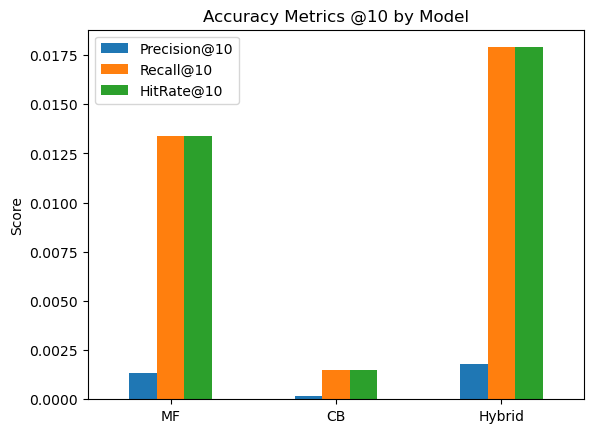

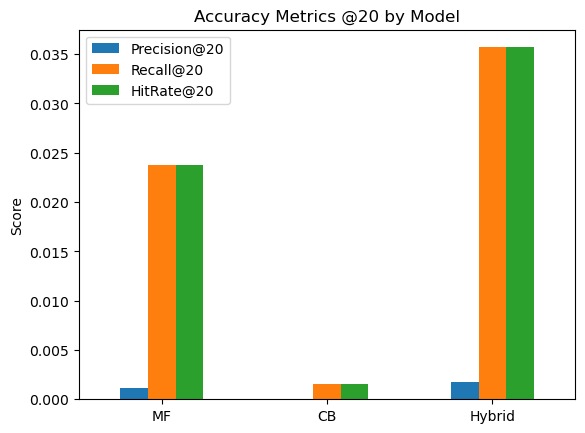

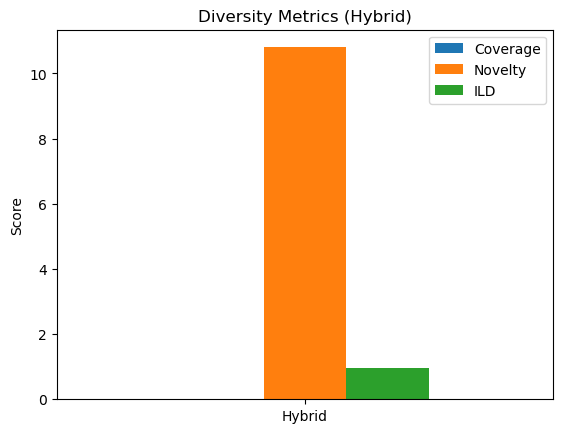

In [27]:
metrics = {
    'MF': {'Precision@10': 0.00134, 'Recall@10': 0.0134, 'HitRate@10': 0.0134,
           'Precision@20': 0.00119, 'Recall@20': 0.0238, 'HitRate@20': 0.0238},
    'CB': {'Precision@10': 0.00015, 'Recall@10': 0.0015, 'HitRate@10': 0.0015,
           'Precision@20': 0.00007, 'Recall@20': 0.0015, 'HitRate@20': 0.0015},
    'Hybrid': {'Precision@10': 0.00179, 'Recall@10': 0.0179, 'HitRate@10': 0.0179,
               'Precision@20': 0.00179, 'Recall@20': 0.0357, 'HitRate@20': 0.0357,
               'Coverage': 0.012, 'Novelty': 10.8, 'ILD': 0.967}
}

df = pd.DataFrame(metrics).T

# --- Plot accuracy metrics @10
df[['Precision@10','Recall@10','HitRate@10']].plot(kind='bar')
plt.title("Accuracy Metrics @10 by Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# --- Plot accuracy metrics @20
df[['Precision@20','Recall@20','HitRate@20']].plot(kind='bar')
plt.title("Accuracy Metrics @20 by Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# --- Plot diversity metrics (Hybrid only)
df[['Coverage','Novelty','ILD']].dropna().plot(kind='bar')
plt.title("Diversity Metrics (Hybrid)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


In [ ]:
def bootstrap_ci(metric_values, n_bootstrap=1000, ci=95, random_state=42):

    rng = np.random.default_rng(random_state)
    metric_values = np.array(metric_values)
    n = len(metric_values)

    # Resample with replacement
    boot_means = []
    for _ in range(n_bootstrap):
        sample = rng.choice(metric_values, size=n, replace=True)
        boot_means.append(sample.mean())
    
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return metric_values.mean(), (lower, upper)


In [ ]:
def bootstrap(precisions, recalls, hits):
    mean_prec, ci_prec = bootstrap_ci(precisions)
    mean_rec, ci_rec = bootstrap_ci(recalls)
    mean_hit, ci_hit = bootstrap_ci(hits)

    print(f"Precision@20: {mean_prec:.4f} (95% CI {ci_prec[0]:.4f}, {ci_prec[1]:.4f})")
    print(f"Recall@20: {mean_rec:.4f} (95% CI {ci_rec[0]:.4f}, {ci_rec[1]:.4f})")
    print(f"HitRate@20: {mean_hit:.4f} (95% CI {ci_hit[0]:.4f}, {ci_hit[1]:.4f})")


In [44]:
bootstrap(results_hybrid[20]['prec'], results_hybrid[20]['rec'], results_hybrid[20]['hit'])

Precision@20: 0.0018 (95% CI 0.0011, 0.0025)
Recall@20: 0.0358 (95% CI 0.0224, 0.0507)
HitRate@20: 0.0358 (95% CI 0.0224, 0.0507)


In [45]:
bootstrap(results_mf[20]['prec'], results_mf[20]['rec'], results_mf[20]['hit'])

Precision@20: 0.0012 (95% CI 0.0006, 0.0018)
Recall@20: 0.0238 (95% CI 0.0119, 0.0358)
HitRate@20: 0.0238 (95% CI 0.0119, 0.0358)


In [46]:
bootstrap(results_cb[20]['prec'], results_cb[20]['rec'], results_cb[20]['hit'])

Precision@20: 0.0005 (95% CI 0.0001, 0.0009)
Recall@20: 0.0104 (95% CI 0.0030, 0.0179)
HitRate@20: 0.0104 (95% CI 0.0030, 0.0179)


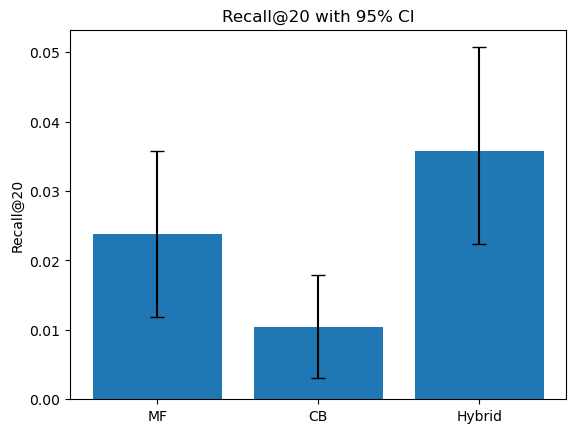

In [47]:
models = ["MF", "CB", "Hybrid"]
means = [0.0238, 0.0104, 0.0358]   # recall@20 means
lowers = [0.0119, 0.0030, 0.0224]  # lower CI
uppers = [0.0358, 0.0179, 0.0507]  # upper CI

errors = [[m - l for m,l in zip(means, lowers)], 
          [u - m for m,u in zip(means, uppers)]]

plt.bar(models, means, yerr=errors, capsize=5)
plt.ylabel("Recall@20")
plt.title("Recall@20 with 95% CI")
plt.show()